Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1043 entries, 0 to 1042
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   No                                  1042 non-null   float64
 1   Nama Lengkap                        1042 non-null   object 
 2   Prodi                               1042 non-null   object 
 3   Jenis Kelamin                       1042 non-null   object 
 4   Jarak Tempat Tinggal kekampus (Km)  1042 non-null   object 
 5   Asal Sekolah                        1042 non-null   object 
 6   Tahun Lulus                         1042 non-null   float64
 7   SKS                                 1042 non-null   float64
 8   Ikut Organisasi                     1042 non-null   object 
 9   Ikut UKM                            1042 non-null   object 
 10  IPK                                 1042 non-null   float64
 11  Pekerjaan Orang Tua          

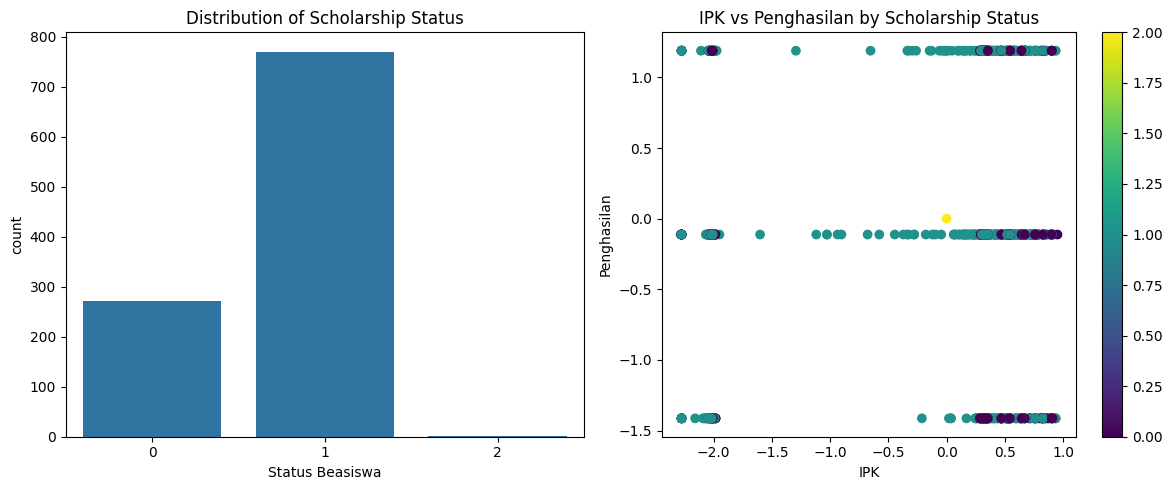


Cross-validation scores: 0.55 (+/- 0.03)

Accuracy Score: 0.61

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.51      0.47        73
           1       0.71      0.66      0.69       136

    accuracy                           0.61       209
   macro avg       0.58      0.58      0.58       209
weighted avg       0.62      0.61      0.61       209



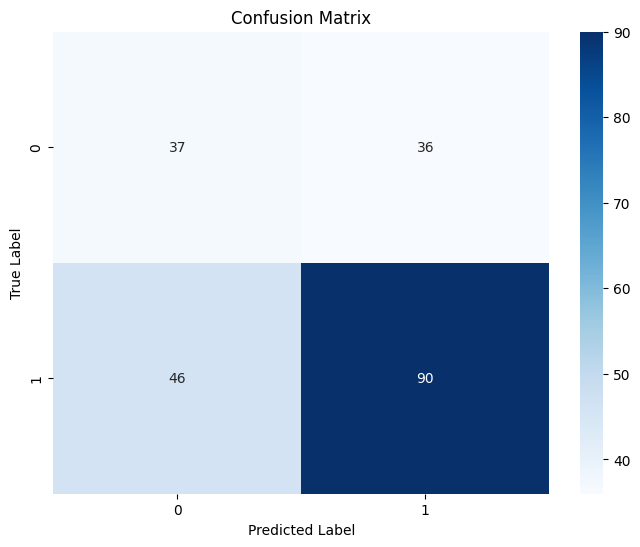


Prediksi untuk mahasiswa baru:
IPK: 3.75, Penghasilan: 2
Hasil: Tidak
Probabilitas: Tidak = 0.61, Terima = 0.39


c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import joblib

def load_and_preprocess_data(filepath):
    """Load and preprocess the dataset"""
    # Load dataset
    df = pd.read_csv(filepath, encoding="ISO-8859-1", delimiter=";")
    
    # Display initial dataset info
    print("Dataset Info:")
    print(df.info())
    print("\nMissing values:")
    print(df.isna().sum())
    
    # Map income levels
    income_mapping = {"Rendah": 0, "Sedang": 1, "Tinggi": 2}
    df["Penghasilan"] = df["Penghasilan"].map(income_mapping)
    
    # Select relevant features
    df = df[["IPK", "Penghasilan", "Status Beasiswa"]]
    
    # Handle missing values
    imputer = SimpleImputer(strategy="mean")
    df[["IPK", "Penghasilan"]] = imputer.fit_transform(df[["IPK", "Penghasilan"]])
    
    return df

def prepare_features(df):
    """Prepare features and target variables"""
    # Encode target variable
    le = LabelEncoder()
    df["Status Beasiswa"] = le.fit_transform(df["Status Beasiswa"])
    
    # Split features and target
    X = df[["IPK", "Penghasilan"]]
    y = df["Status Beasiswa"]
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    
    return X_scaled, y, scaler

def visualize_data(X, y):
    """Create visualizations for data analysis"""
    plt.figure(figsize=(12, 5))
    
    # Distribution of classes
    plt.subplot(1, 2, 1)
    sns.countplot(x=y)
    plt.title("Distribution of Scholarship Status")
    
    # Scatter plot of features
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(X["IPK"], X["Penghasilan"], c=y, cmap='viridis')
    plt.colorbar(scatter)
    plt.xlabel("IPK")
    plt.ylabel("Penghasilan")
    plt.title("IPK vs Penghasilan by Scholarship Status")
    
    plt.tight_layout()
    plt.show()

import joblib

def train_and_evaluate_model(X, y):
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Cek jumlah sampel tiap kelas
    unique, counts = np.unique(y_train, return_counts=True)
    min_samples = min(counts)
    
    # Gunakan SMOTE atau oversampling
    if min_samples >= 6:
        smote = SMOTE(random_state=42)
        X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    else:
        from sklearn.utils import resample
        majority_class = 0 if (y_train == 0).sum() > (y_train == 1).sum() else 1
        minority_class = 1 if majority_class == 0 else 0
        X_train_df = pd.DataFrame(X_train, columns=['IPK', 'Penghasilan'])
        train_data = pd.concat([X_train_df, pd.Series(y_train, name='Status')], axis=1)
        majority_data = train_data[train_data['Status'] == majority_class]
        minority_data = train_data[train_data['Status'] == minority_class]
        minority_upsampled = resample(minority_data,
                                      replace=True,
                                      n_samples=len(majority_data),
                                      random_state=42)
        balanced_data = pd.concat([majority_data, minority_upsampled])
        X_train_balanced = balanced_data[['IPK', 'Penghasilan']]
        y_train_balanced = balanced_data['Status']
    
    # Train model
    model = GaussianNB()
    model.fit(X_train_balanced, y_train_balanced)
    
    # Simpan model dan scaler ke file
    joblib.dump(model, "model_naive_bayes.pkl")
    joblib.dump(scaler, "scaler.pkl")
    print("Model dan scaler berhasil disimpan.")
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, cv=5)
    print(f"\nCross-validation scores: {cv_scores.mean():.2f} (+/- {cv_scores.std() * 2:.2f})")
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Evaluate model
    print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred):.2f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix visualization
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return model


def predict_new_student(model, scaler, ipk, penghasilan):
    """Make prediction for a new student"""
    # Prepare input data
    new_data = pd.DataFrame([[ipk, penghasilan]], columns=['IPK', 'Penghasilan'])
    new_data_scaled = scaler.transform(new_data)
    
    # Make prediction
    prediction = model.predict(new_data_scaled)
    probability = model.predict_proba(new_data_scaled)
    
    result = "Terima" if prediction[0] == 1 else "Tidak"
    print(f"\nPrediksi untuk mahasiswa baru:")
    print(f"IPK: {ipk}, Penghasilan: {penghasilan}")
    print(f"Hasil: {result}")
    print(f"Probabilitas: Tidak = {probability[0][0]:.2f}, Terima = {probability[0][1]:.2f}")

def main():
    # Load and process data
    df = load_and_preprocess_data("data_beasiswa.csv")
    
    # Prepare features
    X, y, scaler = prepare_features(df)
    
    # Visualize data
    visualize_data(X, y)
    
    # Train and evaluate model
    model = train_and_evaluate_model(X, y)
    
    # Make prediction for new student
    predict_new_student(model, scaler, ipk=3.75, penghasilan=2)

if __name__ == "__main__":
    main()